# Table 1 — YOLOE-v8-S Reproduction

**Goals:**
1. Evaluate YOLOE-v8-S on LVIS minival using the official YOLOE repo
2. Compute Fixed AP
3. Measure PyTorch FPS on Colab and compare with paper Table 1
4. Demonstrate text prompt / visual prompt / prompt-free inference modes

**Notes:**
- Paper FPS is TensorRT on T4; our FPS is PyTorch on Colab — not a direct comparison.
- Training time is N/A since we use a pretrained checkpoint.

In [1]:
# Cell 1 - Setup

%cd /content
!rm -rf yoloe
!git clone https://github.com/THU-MIG/yoloe.git

%cd /content/yoloe
!pip install -q -e ".[extra]"
!pip install -q -e third_party/ml-mobileclip
!pip install -q /content/yoloe/third_party/lvis-api
!pip install -q git+https://github.com/openai/CLIP.git

# LVIS NumPy patch
import glob, os
for p in glob.glob("/usr/local/lib/python*/dist-packages/lvis/eval.py"):
    os.system(f"sed -i 's/np\\.float/float/g' {p}")
    print("patched:", p)

/content
Cloning into 'yoloe'...
remote: Enumerating objects: 31949, done.
remote: Counting objects: 100% (1068/1068), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 31949 (delta 1020), reused 947 (delta 947), pack-reused 30881 (from 2)
Receiving objects: 100% (31949/31949), 37.71 MiB | 19.43 MiB/s, done.
Resolving deltas: 100% (23084/23084), done.
/content/yoloe
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.7 MB/s eta 0:00:00
  Build

In [2]:
# Cell 2 - Checkpoints

%cd /content/yoloe
!mkdir -p pretrain

# YOLOE-v8-S segmentation checkpoint
!wget -q --show-progress \
  https://huggingface.co/jameslahm/yoloe/resolve/main/yoloe-v8s-seg.pt \
  -O pretrain/yoloe-v8s-seg.pt

# MobileCLIP-BLT weights
!wget -q --show-progress \
  https://docs-assets.developer.apple.com/ml-research/datasets/mobileclip/mobileclip_blt.pt \
  -O pretrain/mobileclip_blt.pt

!ls -lh pretrain/

/content/yoloe
pretrain/yoloe-v8s- 100%[===================>]  29.69M  --.-KB/s    in 0.1s    
pretrain/mobileclip 100%[===================>] 571.46M   624MB/s    in 0.9s    
total 602M
-rw-r--r-- 1 root root 572M Feb 27  2024 mobileclip_blt.pt
-rw-r--r-- 1 root root  30M Jun  8 04:41 yoloe-v8s-seg.pt


In [3]:
# Cell 3 - Dataset setup

import glob
from pathlib import Path

%cd /content/yoloe

Path("/content/datasets/lvis/annotations").mkdir(parents=True, exist_ok=True)
Path("/content/datasets/lvis/images").mkdir(parents=True, exist_ok=True)
Path("/content/datasets/lvis/images/train2017").mkdir(parents=True, exist_ok=True)
Path("/content/datasets/lvis/images/test2017").mkdir(parents=True, exist_ok=True)

# COCO val2017 images
if not Path("/content/datasets/lvis/images/val2017").exists():
    !wget -q --show-progress \
      http://images.cocodataset.org/zips/val2017.zip \
      -O /content/datasets/lvis/images/val2017.zip
    !unzip -q /content/datasets/lvis/images/val2017.zip -d /content/datasets/lvis/images
    !rm -f /content/datasets/lvis/images/val2017.zip

# minival split file
val_images = sorted(glob.glob("/content/datasets/lvis/images/val2017/*.jpg"))
with open("/content/datasets/lvis/minival.txt", "w") as f:
    for p in val_images:
        f.write(p + "\n")

print("val2017 images:", len(val_images))
!ls /content/datasets/lvis/annotations/

/content/yoloe
/content/datasets/l 100%[===================>] 777.80M  13.9MB/s    in 60s     
val2017 images: 5000


In [5]:
# Cell 4 - LVIS annotation

from google.colab import files
import shutil, json
from pathlib import Path

# Local upload
# uploaded = files.upload()
# Manual upload

dest = Path("/content/datasets/lvis/annotations/lvis_v1_minival.json")
shutil.copy("/content/lvis_v1_minival.json", dest)

# Verify
with open(dest) as f:
    ann = json.load(f)
size_mb = dest.stat().st_size / (1024**2)
print(f"images: {len(ann['images'])}, categories: {len(ann['categories'])}, annotations: {len(ann['annotations'])}")
print(f"saved: {dest}  ({size_mb:.1f} MB)")

images: 4809, categories: 1203, annotations: 50672
saved: /content/datasets/lvis/annotations/lvis_v1_minival.json  (33.8 MB)


In [6]:
# Cell 5 - LVIS validation
# Runtime: ~20-30 min on Colab

import sys, time, json
from pathlib import Path

sys.path.insert(0, "/content/yoloe")
sys.path.insert(0, "/content/yoloe/third_party/ml-mobileclip")

%cd /content/yoloe
!ln -sf /content/yoloe/pretrain/mobileclip_blt.pt /content/yoloe/mobileclip_blt.pt

from ultralytics import YOLOE

model = YOLOE("pretrain/yoloe-v8s-seg.pt")

start = time.perf_counter()

metrics = model.val(
    data="ultralytics/cfg/datasets/lvis.yaml",
    batch=4,
    split="minival",
    rect=False,
    save_json=True,
    plots=False,     # avoids curves_results AttributeError on some ultralytics versions
    project="/content/yoloe/runs/table1",
    name="yoloe_v8s_lvis_minival_v2",
    exist_ok=True,
)

end = time.perf_counter()
eval_seconds = end - start

save_dir = Path(getattr(metrics, "save_dir", "/content/yoloe/runs/table1/yoloe_v8s_lvis_minival_v2"))
pred_candidates = list(save_dir.rglob("predictions.json"))

print(f"Wall-clock: {eval_seconds:.1f}s  ({eval_seconds/60:.1f} min)")
print("predictions.json:", pred_candidates)

/content/yoloe
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.39 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)

Dataset 'ultralytics/cfg/datasets/lvis.yaml' images not found ⚠️, missing path '/content/datasets/lvis/val.txt'


100%|██████████| 497M/497M [00:14<00:00, 36.3MB/s]


WARNING ⚠️ Skipping /content/datasets/lvis-labels-segments.zip unzip as destination directory /content/datasets/lvis is not empty.
WARNING ⚠️ Skipping /content/datasets/lvis/images/val2017.zip unzip as destination directory /content/datasets/lvis/images/val2017 is not empty.
Dataset download success ✅ (1479.0s), saved to /content/datasets



100%|██████████| 755k/755k [00:00<00:00, 170MB/s]

Validate using the text prompt.


...

val: WARNING ⚠️ No labels found in /content/datasets/lvis/labels/val2017.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
val: WARNING ⚠️ Cache directory /content/datasets/lvis/labels is not writeable, cache not saved.
WARNING ⚠️ No labels found in /content/datasets/lvis/labels/val2017.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1250/1250 [27:28<00:00,  1.32s/it]

Speed: 0.2ms preprocess, 5.7ms inference, 0.0ms loss, 9.6ms postprocess per image
Saving /content/yoloe/runs/table1/yoloe_v8s_lvis_minival_v2/predictions.json...



Evaluating lvis mAP using /content/yoloe/runs/table1/yoloe_v8s_lvis_minival_v2/predictions.json and /content/datasets/lvis/annotations/lvis_v1_minival.json...


lvis unable to run: Results do not correspond to current LVIS set.
Results saved to /content/yoloe/runs/table1/yoloe_v8s_lvis_minival_v2
Wall-clock: 3198.0s  (53.3 min)
predictions.json: [PosixPath('/content/yoloe/runs/table1/yoloe_v8s_lvis_minival_v2/predictions.json')]


In [7]:
# Cell 6 - Find predictions

from pathlib import Path
import json

candidates = list(Path("/content/yoloe/runs").rglob("predictions.json"))
for i, p in enumerate(candidates):
    print(i, p, f"{p.stat().st_size / (1024**2):.1f} MB")

assert len(candidates) > 0, "predictions.json not found — re-run Cell 5"

# Latest predictions file
pred_path = max(candidates, key=lambda p: p.stat().st_mtime)
print("Using:", pred_path)

0 /content/yoloe/runs/table1/yoloe_v8s_lvis_minival_v2/predictions.json 740.1 MB
Using: /content/yoloe/runs/table1/yoloe_v8s_lvis_minival_v2/predictions.json


## Own Code
Filters YOLOE predictions to LVIS minival images only, so the prediction file matches the evaluation split before fixed AP calculation.

In [8]:
# Cell 7 - Filter minival predictions

import json
from pathlib import Path

ann_path = Path("/content/datasets/lvis/annotations/lvis_v1_minival.json")
out_path = Path("/content/yoloe/predictions_minival_only_yoloe_v2.json")

with open(ann_path) as f:
    ann = json.load(f)
with open(pred_path) as f:
    preds = json.load(f)

gt_img_ids = set(img["id"] for img in ann["images"])
filtered = [p for p in preds if p["image_id"] in gt_img_ids]

print(f"GT images: {len(gt_img_ids)}")
print(f"Original predictions: {len(preds)}")
print(f"Filtered predictions: {len(filtered)}")
print(f"Removed predictions:  {len(preds) - len(filtered)}")

with open(out_path, "w") as f:
    json.dump(filtered, f)
print("Saved:", out_path)

GT images: 4809
Original predictions: 1500000
Filtered predictions: 1442700
Removed predictions:  57300
Saved: /content/yoloe/predictions_minival_only_yoloe_v2.json


In [9]:
# Cell 8 - Free memory

import gc, torch
from pathlib import Path

# Release model memory
try:
    del model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print("model freed")

# Re-filter predictions
import json

pred_path = Path("/content/yoloe/runs/table1/yoloe_v8s_lvis_minival_v2/predictions.json")
ann_path  = Path("/content/datasets/lvis/annotations/lvis_v1_minival.json")
out_path  = Path("/content/yoloe/predictions_minival_only.json")

with open(ann_path) as f:
    ann = json.load(f)
with open(pred_path) as f:
    preds = json.load(f)

gt_img_ids = set(img["id"] for img in ann["images"])
filtered = [p for p in preds if p["image_id"] in gt_img_ids]

print(f"GT images: {len(gt_img_ids)}, Filtered: {len(filtered)}")
with open(out_path, "w") as f:
    json.dump(filtered, f)
print("saved:", out_path)

model freed
GT images: 4809, Filtered: 1442700
saved: /content/yoloe/predictions_minival_only.json


## Own Code
Keeps the top 10,000 predictions per category and runs LVIS fixed AP evaluation to match the paper's Table 1 setting.

In [10]:
# Cell 9 - Fixed AP

import json, gc
from collections import defaultdict
from pathlib import Path
from lvis import LVIS, LVISResults, LVISEval

ann_path  = "/content/datasets/lvis/annotations/lvis_v1_minival.json"
pred_path = "/content/yoloe/predictions_minival_only_yoloe_v2.json"

with open(pred_path) as f:
    results = json.load(f)

# Top 10,000 predictions per category
by_cat = defaultdict(list)
for det in results:
    by_cat[det["category_id"]].append(det)

fixed_results = []
for cat_id, dets in by_cat.items():
    dets.sort(key=lambda x: -x["score"])
    fixed_results.extend(dets[:10000])

print(f"Fixed-AP predictions: {len(fixed_results)}")

lvis_gt  = LVIS(ann_path)
lvis_res = LVISResults(lvis_gt, fixed_results, max_dets=-1)
lvis_eval = LVISEval(lvis_gt, lvis_res, iou_type="bbox")
lvis_eval.run()
lvis_eval.print_results()

ap = lvis_eval.get_results()

print("\n===== Fixed AP =====")
for k in ["AP", "AP50", "AP75", "APs", "APm", "APl", "APr", "APc", "APf"]:
    print(f"  {k}: {ap.get(k, 0)*100:.2f}")

with open("/content/yoloe/fixed_ap_metrics.json", "w") as f:
    json.dump(ap, f, indent=2)
print("saved fixed_ap_metrics.json")

Fixed-AP predictions: 1413870


 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=300 catIds=all] = 0.256
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=300 catIds=all] = 0.351
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=300 catIds=all] = 0.278
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=     s | maxDets=300 catIds=all] = 0.151
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=     m | maxDets=300 catIds=all] = 0.325
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=     l | maxDets=300 catIds=all] = 0.458
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=300 catIds=  r] = 0.190
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=300 catIds=  c] = 0.258
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=300 catIds=  f] = 0.267
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=300 catIds=all] = 0.350
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=     s | maxDets=300 catIds=all] = 0.192
 Average R

## Own Code
Runs repeated dummy-image inference to measure PyTorch FPS in our Colab environment.

In [11]:
# Cell 10 - FPS benchmark
# Class embeddings before inference

import sys, time, json, statistics, torch
import numpy as np
from pathlib import Path

sys.path.insert(0, "/content/yoloe")
sys.path.insert(0, "/content/yoloe/third_party/ml-mobileclip")
%cd /content/yoloe

from ultralytics import YOLOE

# LVIS category names
with open("/content/datasets/lvis/annotations/lvis_v1_minival.json") as f:
    ann = json.load(f)
cats = [c["name"] for c in sorted(ann["categories"], key=lambda x: x["id"])]
print(f"LVIS categories: {len(cats)}")

model = YOLOE("pretrain/yoloe-v8s-seg.pt")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model.to(DEVICE)
model.set_classes(cats, model.get_text_pe(cats))
model.eval()

dummy = torch.zeros(1, 3, 640, 640, device=DEVICE)

# Warmup
print("Warming up...")
with torch.no_grad():
    for _ in range(10):
        _ = model.model(dummy)
        torch.cuda.synchronize()

# Benchmark
ITERS = 200
times = []
with torch.no_grad():
    for _ in range(ITERS):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model.model(dummy)
        torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

ms_per_img = statistics.mean(times) * 1000
fps = 1000 / ms_per_img

print(f"\n===== YOLOE-v8-S PyTorch FPS (batch=1, 640×640) =====")
print(f"[Inference only]  {fps:.1f} FPS  ({ms_per_img:.2f} ms/img)")

result = {"fps_inference_only": round(fps, 1), "ms_per_img": round(ms_per_img, 2), "iters": ITERS}
with open("/content/yoloe/fps_result.json", "w") as f:
    json.dump(result, f, indent=2)
print("saved fps_result.json")

/content/yoloe
LVIS categories: 1203
Build text model mobileclip:blt
Warming up...

===== YOLOE-v8-S PyTorch FPS (batch=1, 640×640) =====
[Inference only]  71.2 FPS  (14.04 ms/img)
saved fps_result.json


In [12]:
# Cell 11 - Results summary

import json

with open("/content/yoloe/fixed_ap_metrics.json") as f:
    ap = json.load(f)
with open("/content/yoloe/fps_result.json") as f:
    fps = json.load(f)

our_AP  = round(ap.get("AP",  0) * 100, 2)
our_APr = round(ap.get("APr", 0) * 100, 2)
our_APc = round(ap.get("APc", 0) * 100, 2)
our_APf = round(ap.get("APf", 0) * 100, 2)

print("=" * 65)
print(f"{'Model':<30} {'AP':>6} {'APr':>6} {'APc':>6} {'APf':>6} {'FPS':>8}")
print("-" * 65)
print(f"{'YOLOE-v8-S (paper, TRT T4)':<30} {'27.9':>6} {'22.3':>6} {'27.8':>6} {'29.0':>6} {'305.8':>8}")
print(f"{'YOLOE-v8-S (ours, PyTorch A100)':<30} {our_AP:>6} {our_APr:>6} {our_APc:>6} {our_APf:>6} {fps['fps_inference_only']:>8}")
print("=" * 65)

Model                              AP    APr    APc    APf      FPS
-----------------------------------------------------------------
YOLOE-v8-S (paper, TRT T4)       27.9   22.3   27.8   29.0    305.8
YOLOE-v8-S (ours, PyTorch A100)  25.61  18.96  25.79  26.65     71.2


# Demo

## Own Code
Uploads demo images, runs the three YOLOE prompt modes, and visualizes their results for comparison.

In [13]:
# Cell 12 - Prompt-free model

import os, gc, sys, torch, subprocess

if not os.path.exists("/content/yoloe"):
    print("Runtime restarted — re-cloning and installing...")
    subprocess.run(["git", "clone", "https://github.com/THU-MIG/yoloe.git", "/content/yoloe"], check=True)
    os.chdir("/content/yoloe")
    subprocess.run(["pip", "install", "-q", "-e", ".[extra]"], check=True)
    subprocess.run(["pip", "install", "-q", "-e", "third_party/ml-mobileclip"], check=True)
    subprocess.run(["pip", "install", "-q", "/content/yoloe/third_party/lvis-api"], check=True)
    print("✅ Reinstall complete")

%cd /content/yoloe

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if not os.path.exists("mobileclip_blt.pt"):
    print("Downloading MobileCLIP...")
    !wget -q --show-progress \
      https://docs-assets.developer.apple.com/ml-research/datasets/mobileclip/mobileclip_blt.pt \
      -O mobileclip_blt.pt

if not os.path.exists("pretrain/yoloe-v8s-seg-pf.pt"):
    print("Downloading prompt-free model...")
    !wget -q --show-progress \
      https://huggingface.co/jameslahm/yoloe/resolve/main/yoloe-v8s-seg-pf.pt \
      -O pretrain/yoloe-v8s-seg-pf.pt

from ultralytics import YOLOE
model_pf = YOLOE("pretrain/yoloe-v8s-seg-pf.pt")
model_pf.to(DEVICE)
print(f"✅ Model loaded | device: {DEVICE}")

/content/yoloe
pretrain/yoloe-v8s- 100%[===================>]  26.29M  --.-KB/s    in 0.1s    
✅ Model loaded | device: cuda


Upload an image for demo (jpg / png)


Saving img.jpg to img.jpg


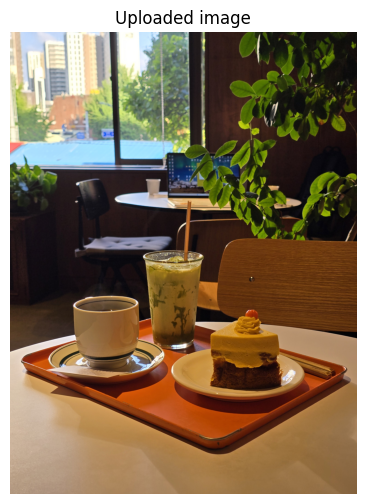

Saved: /content/yoloe/demo_img_img.jpg  ((3000, 4000))


In [14]:
# Cell 13 - Demo image

import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image, ImageOps

print("Upload an image for demo (jpg / png)")
uploaded = files.upload()

filename  = list(uploaded.keys())[0]
safe_name = filename.replace(" ", "_").replace("(", "").replace(")", "")
IMG_PATH  = f"/content/yoloe/demo_img_{safe_name}"
with open(IMG_PATH, "wb") as f:
    f.write(uploaded[filename])

# Preview
img = ImageOps.exif_transpose(Image.open(IMG_PATH).convert("RGB"))
plt.figure(figsize=(8, 6))
plt.imshow(img); plt.axis("off"); plt.title("Uploaded image"); plt.show()
print(f"Saved: {IMG_PATH}  ({img.size})")

=== TEXT PROMPT ===
  targets: ['cup', 'plant', 'tray', 'window', 'straw', 'laptop', 'chair', 'table', 'cake']
Build text model mobileclip:blt
  detected: ['cake', 'cup', 'cup', 'chair', 'cup', 'laptop', 'chair', 'tray', 'plant', 'plant', 'window', 'laptop', 'table', 'plant', 'table']  (15 objects)


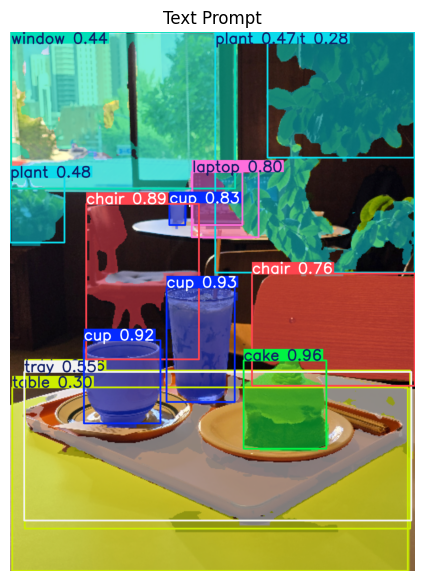

In [15]:
# Cell 14 - Text prompt
# Target names

import matplotlib.pyplot as plt
import cv2, numpy as np
from PIL import Image
from ultralytics import YOLOE

model_main = YOLOE("pretrain/yoloe-v8s-seg.pt")

# Edit for your image
NAMES = ["cup", "plant", "tray", "window", "straw", "laptop", "chair", "table", "cake"]

print(f"=== TEXT PROMPT ===\n  targets: {NAMES}")
model_main.set_classes(NAMES, model_main.get_text_pe(NAMES))

results_text = model_main.predict(IMG_PATH, conf=0.25, imgsz=640,
                                   device=DEVICE, save=False, verbose=False)
results_text[0].save("/content/yoloe/out_text.jpg")

out_text = cv2.cvtColor(results_text[0].plot(), cv2.COLOR_BGR2RGB)
detected = [NAMES[int(c)] for c in results_text[0].boxes.cls.tolist()] if results_text[0].boxes else []
print(f"  detected: {detected}  ({len(detected)} objects)")

plt.figure(figsize=(10, 7))
plt.imshow(out_text); plt.axis("off"); plt.title("Text Prompt"); plt.show()

Upload a reference image containing the object to detect


Saving cake_croped.jpg to cake_croped.jpg


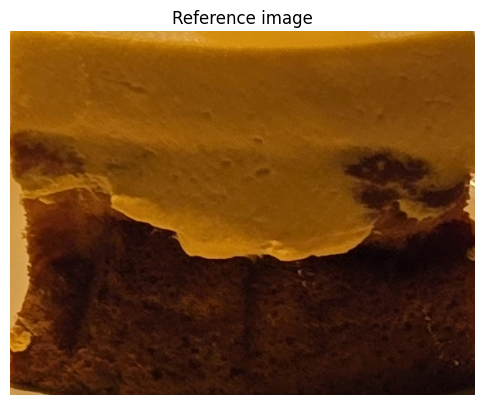

Saved: /content/yoloe/demo_ref_cake_croped.jpg  ((578, 452))


In [16]:
# Cell 15a - Reference image

from google.colab import files
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

print("Upload a reference image containing the object to detect")
uploaded_ref = files.upload()

ref_filename = list(uploaded_ref.keys())[0]
REF_PATH = f"/content/yoloe/demo_ref_{ref_filename.replace(' ', '_')}"
with open(REF_PATH, "wb") as f:
    f.write(uploaded_ref[ref_filename])

ref_img = ImageOps.exif_transpose(Image.open(REF_PATH).convert("RGB"))
plt.figure(figsize=(6, 5))
plt.imshow(ref_img); plt.axis("off"); plt.title("Reference image"); plt.show()
print(f"Saved: {REF_PATH}  ({ref_img.size})")

=== VISUAL PROMPT ===

image 1/1 /content/yoloe/demo_ref_cake_croped.jpg: 640x640 2 object0s, 71.3ms
Speed: 6.9ms preprocess, 71.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


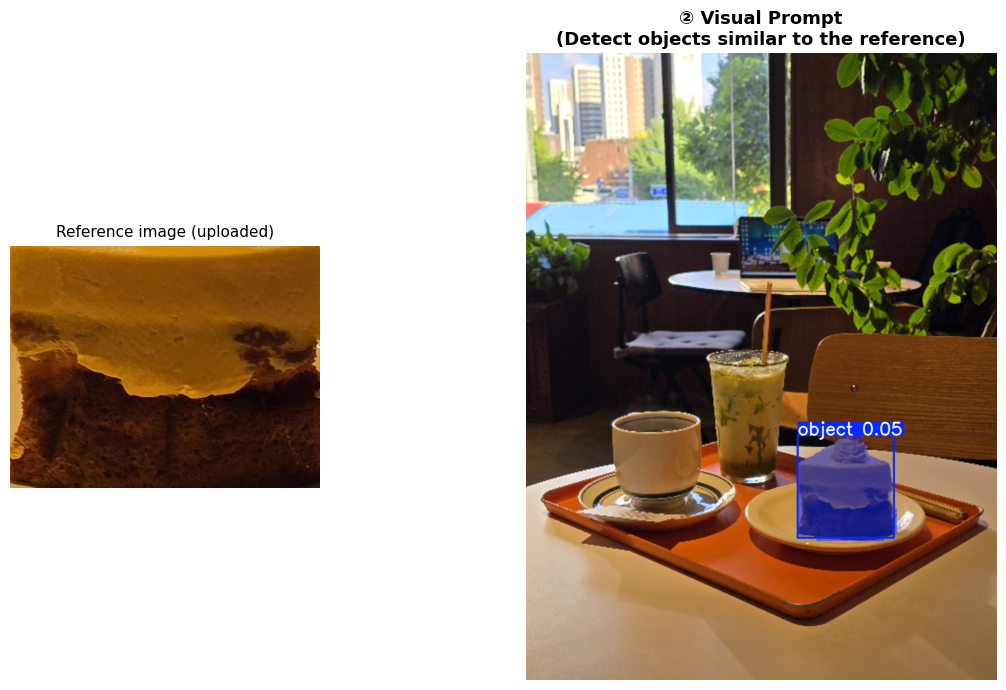

Visual Prompt done!


In [17]:
# Cell 15b - Visual prompt
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np, cv2
from PIL import Image
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe.predict_vp import YOLOEVPSegPredictor

model_main = YOLOE("pretrain/yoloe-v8s-seg.pt")

# Reference image bbox
ref_w, ref_h = ref_img.size  # from Cell 15a
REF_BBOX = np.array([[0, 0, ref_w, ref_h]], dtype=np.float32)

visuals = dict(
    bboxes=[REF_BBOX],
    cls=[np.array([0])]
)

print("=== VISUAL PROMPT ===")

# Visual prompt embedding
model_main.predict(REF_PATH, prompts=visuals,
                   predictor=YOLOEVPSegPredictor, return_vpe=True)
model_main.set_classes(["object"], model_main.predictor.vpe)
model_main.predictor = None

# Similar object detection
results_vp = model_main.predict(IMG_PATH, conf=0.05, imgsz=640,
                                device=DEVICE, save=False, verbose=False)

out_vp = cv2.cvtColor(results_vp[0].plot(), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                         gridspec_kw={"width_ratios": [1, 4]})
axes[0].imshow(ref_img)
axes[0].set_title("Reference image (uploaded)", fontsize=11)
axes[0].axis("off")
axes[1].imshow(out_vp)
axes[1].set_title("② Visual Prompt\n(Detect objects similar to the reference)",
                  fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("/content/yoloe/out_visual.jpg", dpi=150, bbox_inches="tight")
plt.show()
print("Visual Prompt done!")

=== PROMPT-FREE ===
  (Detects all objects automatically with no input)
  detected: ['object']  (13 objects)


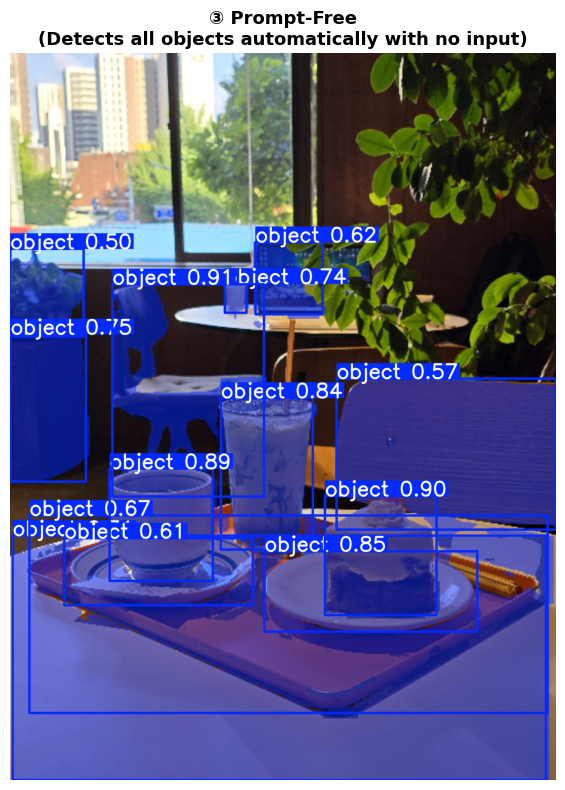

Prompt-Free done!


In [18]:
# Cell 16 - Prompt-free
import matplotlib.pyplot as plt
import cv2
from PIL import Image

print("=== PROMPT-FREE ===\n  (Detects all objects automatically with no input)")

results_pf = model_pf.predict(IMG_PATH, conf=0.25, imgsz=640,
                               device=DEVICE, save=False, verbose=False)

out_pf = cv2.cvtColor(results_pf[0].plot(), cv2.COLOR_BGR2RGB)

boxes = results_pf[0].boxes
if boxes is not None and len(boxes):
    names_detected = [results_pf[0].names[int(c)] for c in boxes.cls.cpu().numpy()]
    unique = list(dict.fromkeys(names_detected))
    print(f"  detected: {unique}  ({len(boxes)} objects)")

plt.figure(figsize=(11, 8))
plt.imshow(out_pf)
plt.title("③ Prompt-Free\n(Detects all objects automatically with no input)",
          fontsize=13, fontweight="bold")
plt.axis("off"); plt.tight_layout()
plt.savefig("/content/yoloe/out_pf.jpg", dpi=150, bbox_inches="tight")
plt.show()
print("Prompt-Free done!")

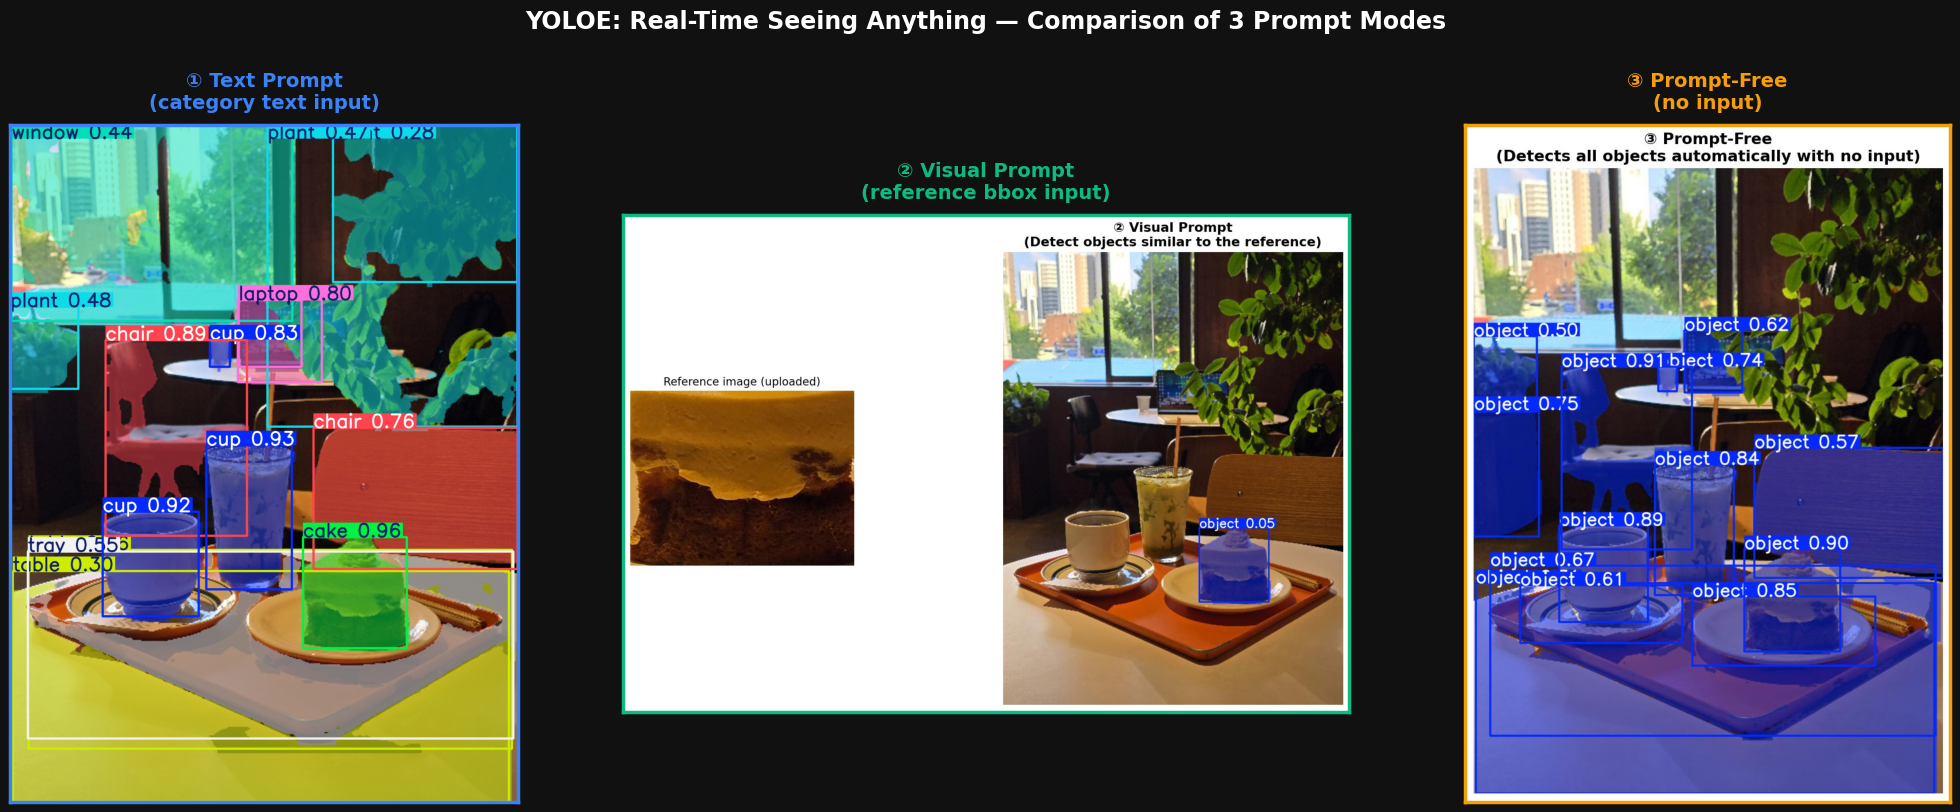

In [19]:
# Cell 17 - Prompt mode comparison
import matplotlib.pyplot as plt
from PIL import Image
import os

paths  = ["out_text.jpg", "out_visual.jpg", "out_pf.jpg"]
titles = ["① Text Prompt\n(category text input)",
          "② Visual Prompt\n(reference bbox input)",
          "③ Prompt-Free\n(no input)"]
colors = ["#3B82F6", "#10B981", "#F59E0B"]

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.patch.set_facecolor("#111111")

for ax, path, title, color in zip(axes, paths, titles, colors):
    ax.set_facecolor("#111111")
    full = f"/content/yoloe/{path}"
    if os.path.exists(full):
        ax.imshow(Image.open(full))
    else:
        ax.text(0.5, 0.5, "No result\n(run the corresponding cell first)",
                ha="center", va="center", color="white", transform=ax.transAxes)
    ax.set_title(title, fontsize=14, fontweight="bold", color=color, pad=12)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2.5)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle("YOLOE: Real-Time Seeing Anything — Comparison of 3 Prompt Modes",
             fontsize=17, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
plt.show()